<a href="https://colab.research.google.com/github/JanieliSilva/Redes_neurais/blob/main/Inteligencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
lista = ['comprimento_sepala', 'largura_sepala', 'comprimento_petala', 'largura_petala', 'classe']
df.columns = lista

df.head(5)


,comprimento_sepala,largura_sepala,comprimento_petala,largura_petala,classe
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
classe = df [ 'classe'].unique()


In [ ]:
entrada = df.iloc[:, 0:4].values
saida = df.iloc[:, 4].values


In [ ]:
df.iloc[:, 4].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [ ]:
dados_treino, dados_teste, saida_treino, saida_teste = train_test_split(entrada, saida, test_size=0.2)

In [ ]:
sc = StandardScaler()
sc.fit(dados_treino)
dados_treino_padronizados = sc.transform(dados_treino)
dados_teste_pradronizado = sc.transform(dados_teste)
saida_treino_onehot = pd.get_dummies(saida_treino).values
saida_teste_onehot = pd.get_dummies(saida_teste).values

In [ ]:
modelo = tf.keras.models.Sequential()
modelo.add(tf.keras.layers.Dense(64, input_dim=4, activation='sigmoid', name='oculta'))
modelo.add(tf.keras.layers.Dense(3, activation='softmax', name='camada_saida'))

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta (Dense)                  │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ camada_saida (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515 (2.01 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)
modelo.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

In [ ]:
history = modelo.fit(dados_treino, saida_treino_onehot, validation_split=0.2, epochs=100, batch_size=10)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3854 - loss: 1.0983 - val_accuracy: 0.6667 - val_loss: 0.8857
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6354 - loss: 0.8936 - val_accuracy: 0.7500 - val_loss: 0.6717
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6667 - loss: 0.7311 - val_accuracy: 0.6667 - val_loss: 0.5781
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7083 - loss: 0.5746 - val_accuracy: 0.7500 - val_loss: 0.4477
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8750 - loss: 0.4765 - val_accuracy: 0.7917 - val_loss: 0.4283
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8438 - loss: 0.4399 - val_accuracy: 1.0000 - val_loss: 0.3407
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9792 - loss: 0.3667 - val_accuracy: 1.0000 - val_loss: 0.3173
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9792 - loss: 0.3323 - val_accuracy: 1.

/tmp/ipykernel_624/3219601374.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Treino', 'Teste', loc='upper left')


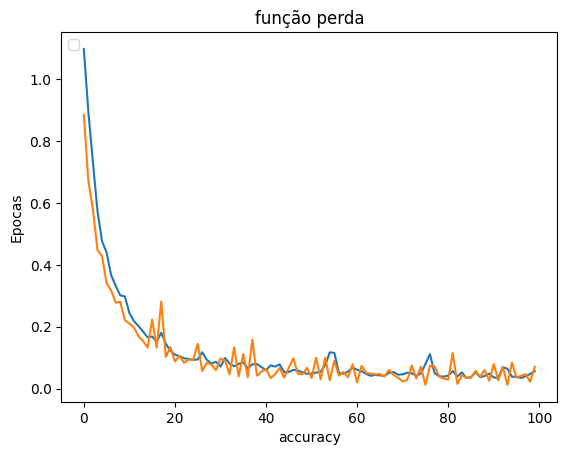

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('função perda')
plt.xlabel('accuracy')
plt.ylabel('Epocas')
plt.legend('Treino', 'Teste', loc='upper left')
plt.show()

In [ ]:
teste = np.array([[5.1, 3.5, 1.4, 0.2]])
teste = sc.transform(teste)
y.predd = model.predict(teste)
y_predd =np.argmax(y_predd, axis=1)+1
print("A classe é:" y_predd[-1])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (156920835.py, line 5)